### Disclaimers

* Downloading the full datasets with pytorch takes a long time. I've uploaded the dataset used for this task on a github repo, and this notebook clones it to use only the required images instead of downloading the full dataset. The code to download the datasets can still be enabled setting `DOWNLOAD_DATASET=True`
* We use NAdam as an optimizer. Models converge much faster compared to using SGD or Adam. I chose step sizes of the order of `10^-3`, but did not do much finetuning.
* I have not used LLMs to generate any code, but I have used extensively the `torch/torchvision` documentation+ some questions on stackoverflow. Some code is sourced from this page [1].
* I have trained the models with Colab with a T4 GPU. Full training time is `<5 minutes`.
* **I have commented most functions / loops in my implementation to explain what the code does.**


[1] https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html


# Task 1

#### Dataset construction
We take 100 images (80 train + 20 test) from the STL10 dataset, and resize them to 64x64 plus grayscale them.


https://cs.stanford.edu/~acoates/stl10/

In [30]:
import random
import torch
import torchvision
import PIL

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import TensorDataset

from torchvision.transforms import functional as F
from torchvision.utils import make_grid

In [31]:
torch.manual_seed(0) # for reproducibility of torch ops

In [32]:
DOWNLOAD_DATASET = False # takes a long time otherwise!

In [33]:
# download the STL10 dataset with torchvision
if DOWNLOAD_DATASET:
  data = torchvision.datasets.STL10(root='stl10', split='train', download=True)

  N_TOTAL_IMAGES = 100 # 80 train + 20 test
  indices = random.sample(range(len(data)), N_TOTAL_IMAGES)
  images = [data[i][0] for i in indices]  # PIL images

  # resize them to 64x64 by lanczos interpolation and convert them to grayscale
  resized = [img.resize((64, 64), resample=Image.LANCZOS).convert('L') for img in images]

  image_tensor = torch.stack([F.to_tensor(img) for img in resized])

  # save them to a pytorch file that can be loaded again
  torch.save({'images': image_tensor}, 'stl10_100_64x64.pt')

In [34]:
# clone the images from github

!git clone https://github.com/marcobrb/cvg-bern-task.git

saved_images = torch.load('cvg-bern-task/stl10_100_64x64.pt')

dataset = TensorDataset(saved_images['images'])

fatal: destination path 'cvg-bern-task' already exists and is not an empty directory.


In [35]:
def show_labeled(tensor, label, ax):
    "Shows a grid of images on a pyplot ax with a text label"
    grid = make_grid(tensor, padding=0)
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
    ax.set_ylabel(label, rotation=0, labelpad=40, fontsize=12, va='center')
    ax.set_xticks([])
    ax.set_yticks([])

#### Noise Model

We use a Gaussian blur with `SIGMA=1`. This is enough so that the blur is evident while not hiding the content of the images. The kernel size is `3` See below for some examples.

* I have tried other values of SIGMA in the range `(0.1, 5)`. The value `SIGMA=1` offers a good compromise between difficulty of the task (i.e. traning time) and visual results.

In [36]:
SIGMA = 1

In [37]:
# blur some test images for showcase
test_images = [dataset[i][0] for i in range(0, 3)]
blurred_test_images = [F.gaussian_blur(img, 3, sigma=(SIGMA)) for img in test_images]

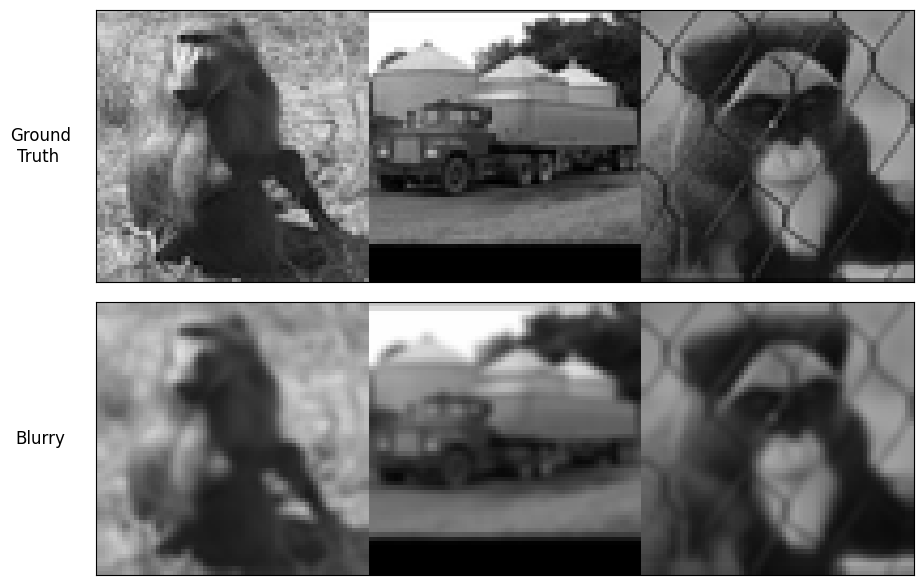

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6))

show_labeled(test_images, "Ground\nTruth ", axes[0])
show_labeled(blurred_test_images, "Blurry", axes[1])

plt.tight_layout()
plt.show()

#### Pytorch Dataset

This dataset, for each index, returns a ground truth image and its blurry couterpart.

**Here we ensure that the test images are not used in training: they are a different dataloader**.

In [39]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

class DeblurDataset(Dataset):
    def __init__(self, sharp_images, blur_sigma=SIGMA, kernel_size=3):
        self.sharp_images = sharp_images
        self.blur = T.GaussianBlur(kernel_size=kernel_size, sigma=blur_sigma)

    def __len__(self):
        return len(self.sharp_images)

    def __getitem__(self, idx):
        # Returns the blurred image and the sharp ground truth
        sharp = self.sharp_images[idx]
        blurry = self.blur(sharp)
        return blurry, sharp

In [40]:
# makes Dataloaders for training
deblur_dataset_train = DeblurDataset(saved_images['images'][:80])
deblur_dataset_test = DeblurDataset(saved_images['images'][80:])

BATCH_SIZE = 10
train_dl = torch.utils.data.DataLoader(deblur_dataset_train, batch_size=BATCH_SIZE)
test_dl = torch.utils.data.DataLoader(deblur_dataset_test, batch_size=BATCH_SIZE)

print(len(train_dl)) # number of batches
print(len(test_dl))

8
2


#### Model
**The specific architecture of the autoencoder is not extremely important**, most reasonable architectures would work in this case.

Our autoencoder is made of:
* An encoder with two convolutional layers followed by a GELU activation. The first layer takes the grayscale image and outputs `num_latent` features per pixel. The second layer takes the features and downsamples them.
* A decoder which is still made of two convolutional layers, the first one still followed by a GELU activation. The first layer upsamples the latent features, and the second generates the final 1-channel image.
* Putting a residual connection [1] between input and output makes training much easier. This is a trick that is often used in the case the input and output of the model are very similar, e.g. deblurring and super-resolution tasks. The model learns the "residual function", i.e. the difference between input and output, instead of the full transformation.

**We use the mean square error as a loss function and reconstruction metric.** Other interesting metrics that could be used are the SSIM [2] and IL-NIQE [3]. However, for our task MSE will be enough.

[1] https://arxiv.org/abs/1512.03385

[2] https://arxiv.org/abs/2006.13846

[3] http://www4.comp.polyu.edu.hk/~cslzhang/paper/IL-NIQE.pdf

In [41]:
# Model

import torch
import torch.nn as nn

class DeblurAutoencoder(nn.Module):
    def __init__(self, num_latent=128):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, num_latent, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(num_latent, num_latent, kernel_size=3, stride=2, padding=1),  # downsample
            nn.GELU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(num_latent, num_latent, kernel_size=4, stride=2, padding=1),  # upsample
            nn.GELU(),
            nn.Conv2d(num_latent, 1, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out+x # residual connection!

In [42]:
model = DeblurAutoencoder()

In [43]:
# We test the loss function and the model ouptut
loss_fn = torch.nn.MSELoss()

# loss test
for i, data in enumerate(train_dl):
  dummy_input, dummy_gt = data
  dummy_output = model(dummy_input)
  break

loss_fn(dummy_input, dummy_output).item()

0.0003871014341711998

In [44]:
# We compute the average loss on the training set of the "identity" model.
# This is the most basic baseline to beat.
loss_dummies = []
for i, data in enumerate(train_dl):
  dummy_loss_input, dummy_loss_gt = data

  loss_dummies.append(loss_fn(dummy_loss_input, dummy_loss_gt).item())

In [45]:
IDENTITY_LOSS = sum(loss_dummies)/len(loss_dummies)
print(IDENTITY_LOSS)

0.002583247405709699


#### Model Input / Output without training / Ground Truth Images
We plot some examples of
* images that the model takes as input
* the output of the model without training
* ground truth sharp images

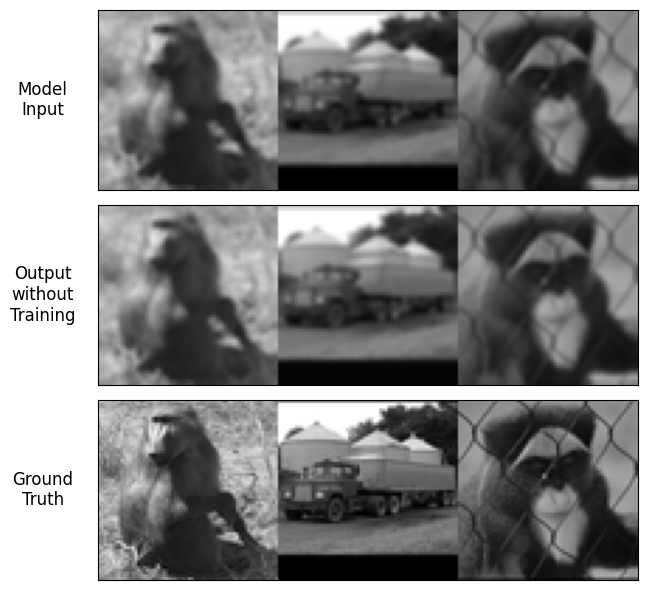

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6))

show_labeled(dummy_input[:3, ...], "Model\nInput", axes[0])
show_labeled(dummy_output[:3, ...], "Output\nwithout\nTraining", axes[1])
show_labeled(dummy_gt[:3, ...], "Ground\nTruth", axes[2])

plt.tight_layout()
plt.show()

#### Training

We use `128` latent features, and a stepsize of `0.002`.


In [47]:
model = DeblurAutoencoder(num_latent=128)
optimizer = torch.optim.NAdam(model.parameters(), lr=0.002) # we use NAdam

In [48]:
def train_one_epoch(epoch_index):
    "Trains one full pass through the training dataset"
    running_loss = 0.
    last_loss = 0.
    total_loss = 0
    for i, data in enumerate(train_dl): # train dataloader
        blurred_images, ground_truths = data

        optimizer.zero_grad()

        outputs = model(blurred_images)

        loss = loss_fn(outputs, ground_truths)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        total_loss += loss.item()
        if i % 5:
            last_loss = running_loss / 5 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(train_dl) + i + 1
            running_loss = 0.

    return total_loss / (i+1) # Returns the average loss over the batches

In [49]:
EPOCHS = 100

best_vloss = 1_000_000.

# keep track of losses for plotting
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    print(f'EPOCH {epoch + 1}:')

    model.train(True)
    # train one eopch
    avg_loss = train_one_epoch(epoch)
    train_losses.append(avg_loss)

    running_vloss = 0.0
    model.eval()

    # evaluate on the test dataset
    with torch.no_grad():
        for i, vdata in enumerate(test_dl): # test dataloader
            blurred_test_images, gt_test_images = vdata
            voutputs = model(blurred_test_images)
            vloss = loss_fn(voutputs, gt_test_images)
            running_vloss += vloss
    avg_vloss = running_vloss / (i + 1)
    # log the train / validation losses
    print(f'LOSS train {avg_loss} valid {avg_vloss}')
    test_losses.append(avg_vloss.item())


EPOCH 1:
  batch 2 loss: 0.007524104649201035
  batch 3 loss: 0.049611353874206544
  batch 4 loss: 0.0005207848735153675
  batch 5 loss: 0.0005756092257797718
  batch 7 loss: 0.0009856814984232187
  batch 8 loss: 0.0007485742215067148
LOSS train 0.03747881771414541 valid 0.003076877212151885
EPOCH 2:
  batch 2 loss: 0.0008166767656803131
  batch 3 loss: 0.000781792402267456
  batch 4 loss: 0.002091946080327034
  batch 5 loss: 0.000981496088206768
  batch 7 loss: 0.0009835499338805675
  batch 8 loss: 0.0007493332028388977
LOSS train 0.004002996545750648 valid 0.0030877976678311825
EPOCH 3:
  batch 2 loss: 0.0008054576348513365
  batch 3 loss: 0.0005629564169794321
  batch 4 loss: 0.0004684959538280964
  batch 5 loss: 0.000544744823127985
  batch 7 loss: 0.0009467174299061298
  batch 8 loss: 0.0007348279003053903
LOSS train 0.0025395000993739814 valid 0.0030565080232918262
EPOCH 4:
  batch 2 loss: 0.0008253680542111396
  batch 3 loss: 0.0006843294948339462
  batch 4 loss: 0.0009490975178

## Training Results

We report the results of the final model in table and plot the behaviour of the loss for each training epoch.

In [50]:
import pandas as pd


pd.DataFrame((train_losses[-1], test_losses[-1]), columns=["MSE Loss of Final Model"], index=["Train Set", "Test Set"])

,MSE Loss of Final Model
Train Set,0.000947
Test Set,0.001174


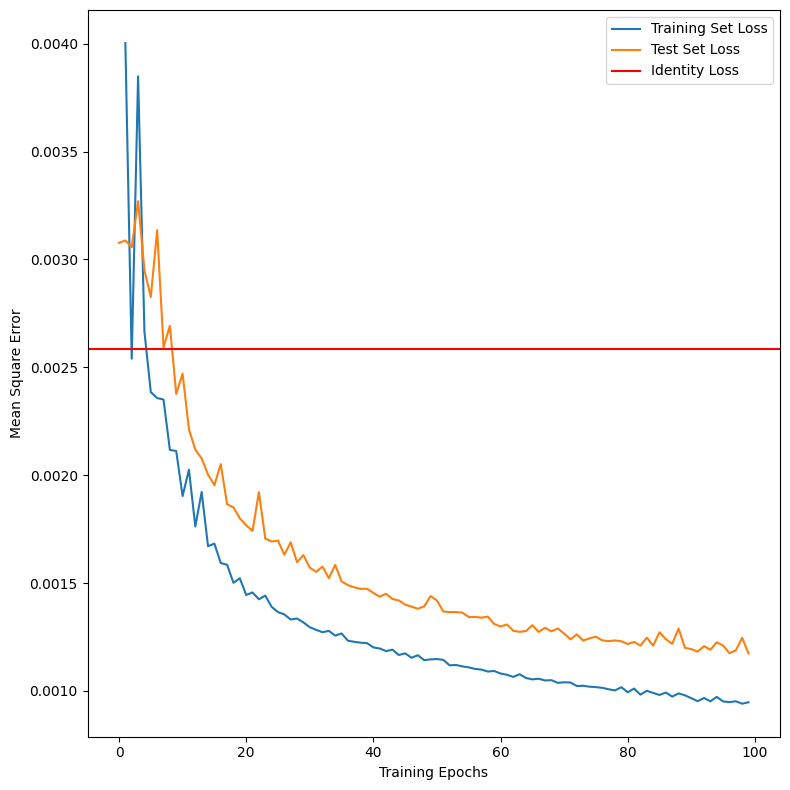

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.plot(
    range(1, len(train_losses)), train_losses[1:], label='Training Set Loss' # I exclude from plotting the first epoch because it usually has very high loss
)
ax.plot(
    range(len(test_losses)), test_losses, label='Test Set Loss'
)
ax.axhline(IDENTITY_LOSS, label='Identity Loss', color='r')

ax.legend()
ax.set_xlabel('Training Epochs')
ax.set_ylabel('Mean Square Error')

plt.tight_layout()
plt.show()

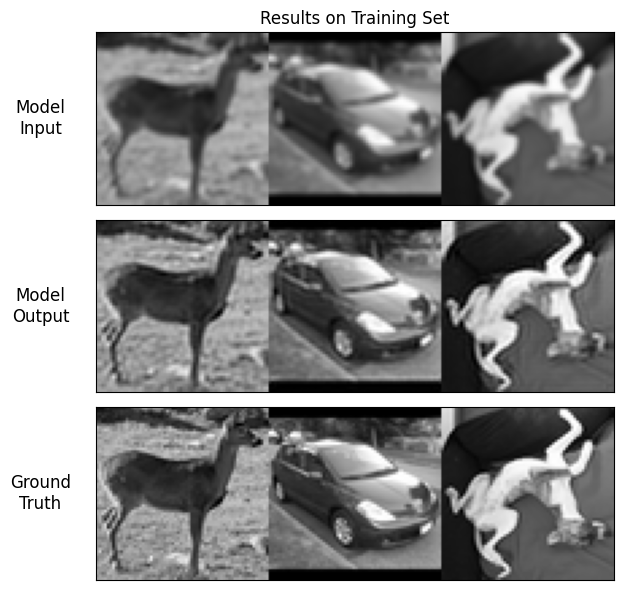

In [52]:
# visualize the results in the training set

model.eval()
for i, data in enumerate(train_dl):
        if i>2: break
        # labels for us is empty!
        blurred_images, ground_truths = data

        out=model(blurred_images)


fig, axes = plt.subplots(3, 1, figsize=(9, 6))
axes[0].set_title("Results on Training Set")

show_labeled(blurred_images[:3, ...], "Model\nInput", axes[0])
show_labeled(out[:3, ...], "Model\nOutput", axes[1])
show_labeled(ground_truths[:3, ...], "Ground\nTruth", axes[2])

plt.tight_layout()
plt.show()

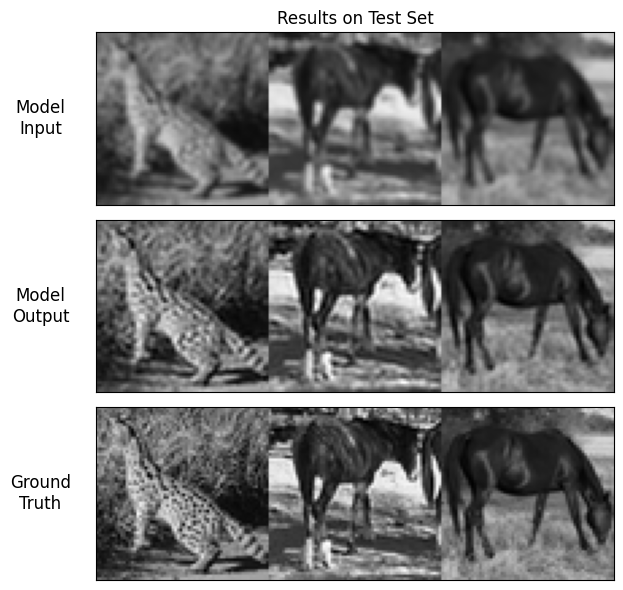

In [53]:
# visualize the results in the test set

model.eval()
for i, data in enumerate(test_dl):
        if i>2: break
        blurred_images, ground_truths = data

        out=model(blurred_images)


fig, axes = plt.subplots(3, 1, figsize=(9, 6))
axes[0].set_title("Results on Test Set")

# fig.title("Results on Test Set")
show_labeled(blurred_images[:3, ...], "Model\nInput", axes[0])
show_labeled(out[:3, ...], "Model\nOutput", axes[1])
show_labeled(ground_truths[:3, ...], "Ground\nTruth", axes[2])

plt.tight_layout()
plt.show()

### Discussion and Final Observations

The training is stable and converges, although we've stopped the training before complete convergence: the model would benefit from more training epochs. The model also clearly outperforms the basic "identity model". The reconstruction error on the training set is constantly lower than the test set, which indicates some level of overfitting on the training data: given that we're training on only 100 images, it might be expected. To avoid overfitting one might use a smaller model.

The qualitative examples clearly show that the autoencoder manages to improve the perceptual quality of the blurred images. There seem to be some slight image artifacts where white and black sections meet, see for example the dog image above.


The most straightforward way to improve this model's performance would be to use a bigger and more diverse training dataset.

# Task 2

Before the task itself, I want to say that solving it was *really* fun. It is not often that a PhD application is this fun, honestly.



##Feasibility and Strategy

**The task is possible, and in fact we present a full solution with no learning involved.**

Let's simplify the problem: instead of two images, suppose we're working with the set $D=\{-1, 1\}$, and a 2-vector

$$x = (x_1, x_2), \quad x_i \in D, x_1\neq x_2$$

which is a simplifaction of "two different images stacked together". The sender S can be represented as a boolean function of $x$,  $S(x) = m \in \{0, 1\}$, and the receiver $R$ as a boolean function of $m$ and $p(x)$, where $p(x)$ is either $(x_1, x_2)$ or $(x_2, x_1)$ each with probability $1/2$. So that:
$$R(m, p(x)) → \{0, 1\}$$
and we can say that $R=0$ means "the images are in the original order, and $R=1$ if they have been switched.

Define:

$$S(x) := sign(x_1)$$
$$R(m, p(x)) := sign(p(x)_1) = m$$

**This receiver always correctly classifies the "order" of $x$. In words: S is saying "is the first element of $x$ greater than 0", which in our case can only be 1, and, and  R is saying "if S told me that the first element is greater than 0, check that the first element of what i receive is too, and if so, then it must be that elements have not been switched".**

To generalize to two images, it is enough to find a way to take any image, encode it as a (real) number such that the encoding function is bijective (!) and then, given two encodings $e_1, e_2$, normalize them by their mean so that $\tilde{e}_1, \tilde{e}_2$ have opposite signs, just like the two elements of the set $D$ above. Call this encoder $E$. Then, composing it with the definitions above:

$$S(E(x)) \quad R(m, p(E(x))$$
**we obtain a solution to the task with no learning required** (this is verified below by coding this exact model).

It remains to find a suitable encoder function: note that an image is, at worst, a vector in $R^N$, and that a bijective function from $R^N$ to $R$ exists for any $N$, so that the set of encoders that satisfy of requirements is nonempty.

However, a direct construction of one of these encoder functions would be hard (and even more coding it). For reasonable images, we can drop the hard constraint of bijectivity and take functions that are "bijective for almost all images". Without going to the trouble of formalizing this definition, we just mean that the set of images that get encoded to the same number is "small".

Take for example the brightness of an image (the average pixel value): it's obvious that it's not a bijective encoder (rotated images have the same brightness), but for our task it'll make the receiver achieve good accuracy. If we want something more accurate, we need to take a more complicated encoder: e.g. flatten (in any way) an image as a vector in $v\in R^N$ and take as the encoder something like:

$$E(x) = \sum_{i=1}^N v_i 2^{-i}$$

This is what we code below, and we'll see that it achieves perfect accuracy.

**Given the above solution, if we want to train deep networks as a Sender and Receiver, we can make them learn an appropriate "encoding function".**

#### Setup
Download CIFAR-10 and extract 100 random images

In [84]:
import torch
import torchvision

from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, Subset
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# copied from above for simplicity
def show_labeled(tensor, label, ax):
    grid = make_grid(tensor, padding=0)
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
    ax.set_ylabel(label, rotation=0, labelpad=40, fontsize=12, va='center')
    ax.set_xticks([])
    ax.set_yticks([])

In [85]:
DOWNLOAD_CIFAR = False


if DOWNLOAD_CIFAR:
  cifar = datasets.CIFAR10('cifar10', download=True) # takes a while on colab, like 25 minutes
  # take 100 random images
  indices = random.sample(range(len(cifar)), 100)
  samples = [cifar[i] for i in indices]  # list of (PIL image, label)

  images = [img for img, _ in samples]

  # convert to tensors
  image_tensor = torch.stack([F.to_tensor(img) for img in images])

  # save
  torch.save({'images': image_tensor}, 'cifar10_100.pt')

In [86]:
# clone the images afrom github

!git clone https://github.com/marcobrb/cvg-bern-task.git 'cvg-bern-task-cifar'

saved_images = torch.load('cvg-bern-task-cifar/cifar10_100.pt')

dataset = TensorDataset(saved_images['images'])

fatal: destination path 'cvg-bern-task-cifar' already exists and is not an empty directory.


### Sample images from CIFAR10

We show some sample images from the dataset.

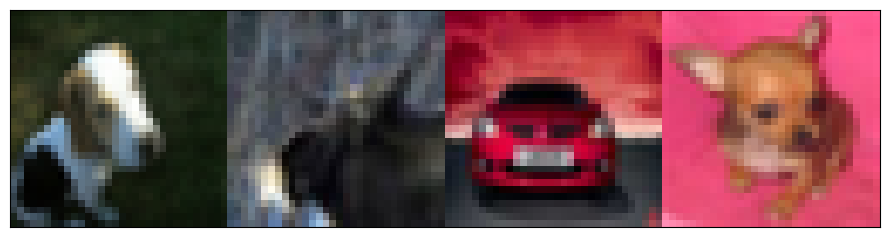

In [87]:
fig, axes = plt.subplots(1, 1, figsize=(9, 6))

show_labeled([dataset[i][0] for i in range(4)], "", axes)

plt.tight_layout()
plt.show()

#### Pytorch Stacked Dataset

We define a training dataset with 85 images and a testing set with 15. **I still decided to use a testing set because a complex model might overfit the training dataset and not generalize**.

The `StackDataset` generates all the possible image couples and stackes them together. For each index returns the stacked images `gt`, the possibly switched images `possibly_switched`, and a bool `has_switched` which indicates wheter the images where switched or not.

We exclude stacking the same image twice: there would be no way to tell if any "switching" occured.

In [88]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import random

class StackDataset(Dataset):
    def __init__(self, images, kernel_size=3):
        self.images = [img[0] for img in images]

        # cross product of the image index
        # the list will be (1,2), (1, 3), etc.
        # the couples (i, i) are excluded
        self.indexes_map = [(i, j) for i in range(len(images)) for j in range(len(images)) if i!=j] # exclude using the same image twice

    def __len__(self):
        return len(self.indexes_map)

    def __getitem__(self, idx):
        idx1, idx2 = self.indexes_map[idx]

        # stack vertically
        gt = torch.cat(
          (self.images[idx1], self.images[idx2]), dim=-2
        )
        has_switched = random.random() < 0.5 # we switch with p=1/2

        pidx1, pidx2 = (idx2, idx1) if has_switched else (idx1, idx2)
        possibly_switched = torch.cat(
          (self.images[pidx1], self.images[pidx2]), dim=-2
        )

        return gt, possibly_switched, has_switched



In [89]:
stack_dataset_train = StackDataset(Subset(dataset, range(0, 85)))
stack_dataset_test = StackDataset(Subset(dataset, range(85, 100)))

# define the training dataloader
BATCH_SIZE = 10
stack_train_dl = torch.utils.data.DataLoader(stack_dataset_train, batch_size=BATCH_SIZE, shuffle=True)
stack_test_dl = torch.utils.data.DataLoader(stack_dataset_test, batch_size=BATCH_SIZE, shuffle=True)

print(len(stack_train_dl)) # number of batches

714


An example of the training data:
* First column: ground truth
* Second column: receiver input
* `Has switched` boolean

Has switched: tensor(False)


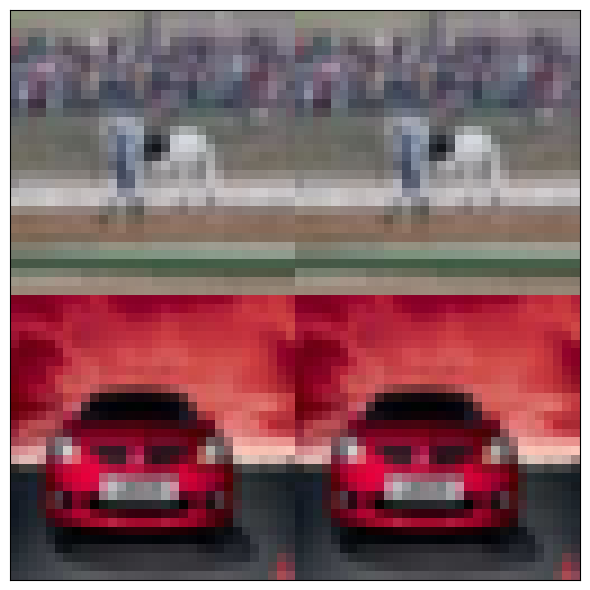

In [90]:
for i, data in enumerate(stack_train_dl):
  gt, received, v = data
  break

fig, axes = plt.subplots(1, 1, figsize=(9, 6))

show_labeled([gt[0, ...], received[0, ...]], "", axes)
print("Has switched:", v[0, ...])
plt.tight_layout()
plt.show()

#### Solution with No Training

Here we code the solution with no traning presented above. The encoder is given by
$$E(x) = \sum_{i=1}^N v_i 2^{-i}$$
which encodes an image (in our case, a 3-channel 32x32 image) to a real number.

* The sender sends the message "is the top image encoding greater than the bottom image?"
* The receiver receives this message and checks consistency with the images it reads.


In [91]:
def unstack_image(stacked_image):
  dum1 = stacked_image[:, :32, :]
  dum2 = stacked_image[:, 32:, :]

  return dum1, dum2


def encode_image(image):
  encoder = torch.tensor([2**(-i) for i in range(3072)])
  return (image.flatten()*encoder).sum()

# Full Solution Sender and Receiver

def Sender(stacked_image):
  "Unstacks the image and compares the encoded values"
  # Returns 1 if the encoded value of the top image is higher
  dum1, dum2 = unstack_image(stacked_image)
  return (
      encode_image(dum1) > encode_image(dum2)
  )

def Receiver(m, possibly_stacked_image):
  # Unstacks the image, encodes them
  # Checks consistency with the sent value
  dum1, dum2 = unstack_image(possibly_stacked_image)

  check_value = (
      encode_image(dum1) > encode_image(dum2)
  )

  return (
      not m == check_value
  )

We test the solution on the whole training set.

In [92]:
preds = [] # Takes a bit
for i, data in enumerate(stack_train_dl):
  gt, received, v = data


  for j in range(BATCH_SIZE):
    # loop for each element in the batch
    gt_j = gt[j, ...]
    received_j = received[j, ...]
    v_j = v[j, ...]

    send = Sender(gt_j)

    prediction = Receiver(send, received_j)

    preds.append(prediction == v_j.item())

It achieves perfect accuracy.

In [93]:
accuracy = sum(preds)/len(preds)

import pandas as pd


pd.DataFrame(accuracy, columns=["Accuracy on Train Set"], index=["Marco's Solution"]) # Perfect Accuracy. Good work Marco!

,Accuracy on Train Set
Marco's Solution,1.0


#### Deep Learning Models

I had trouble training a sender/receiver combination that managed to encode whole 32x32 images, mostly because they took too many epochs to converge, and small models would just collapse (like GANs, training two networks might be very unstable). However, it is possible to drastically simplify the computational requirements by encoding only a part of the image, enough for the model to tell they are different images.

In the Sender/Receiver below, we only encode the first `num_pixels` of the first channel. This turns out to be enough to get very good accuracy even with less than 10 pixels. **In practice, we obtain `>99% accuracy` even with just 2 pixels.**

The models are roughly like this:
* The **Sender** takes the two 32x32 images, takes the first `n_pixels` of each image, concatenates them, and encodes them with a fully connected network. It then applies a final Sigmoid activation function to output a number between `0 and 1`.
  * We keep the output continous to keep the network differentiable. However, for validation, the output of the sender in binarized with `threshold=1/2`, so what the receiver sees is binary, as the task requires.
* The **Receiver** concatenates the first `n_pixels` of the two 32x32 images it receives (possibly switched) with the signal sent by the sender, and applies a fully connected network.

The loss is a binary cross entropy with logits.

In [94]:
# Model

import torch
import torch.nn as nn
import torch
import torch.nn as nn

def encode_image_batch(image):
  encoder = torch.tensor([2**(-i) for i in range(3072)]).unsqueeze(0)
  return torch.sum(image.flatten(start_dim=1)*encoder, dim=1).unsqueeze(-1)


class Sender(nn.Module):
  def __init__(self, num_pixels=10):
    super().__init__()
    self.num_pixels = num_pixels
    self.wow = nn.Sequential(
        nn.Linear(2*num_pixels, 64),
        nn.GELU(),
        nn.Linear(64,1)
    )

  def forward(self, x):
    # unstack the images
    img1 = x[:, :, :32, :]
    img2 = x[:, :, 32:, :]

    # takes the first num_pixels
    img1 = img1[:, 0, :self.num_pixels, 0]
    img2 = img2[:, 0, :self.num_pixels, 0]

    # concats + encodes
    logit = torch.cat((img1, img2), dim=-1)
    prob = torch.sigmoid(self.wow(logit))
    return prob


class Receiver(nn.Module):
  def __init__(self, num_pixels=10):
    super().__init__()
    self.num_pixels = num_pixels
    self.wow = nn.Sequential(
        nn.Linear(2*num_pixels+1, 64),
        nn.GELU(),
        nn.Linear(64,1)
    )
  def forward(self, m_sent, x):
    img1 = x[:, :, :32, :]
    img2 = x[:, :, 32:, :]

    img1 = img1[:, 0, :self.num_pixels, 0]
    img2 = img2[:, 0, :self.num_pixels, 0]


    logit = torch.cat((img1, img2, m_sent), dim=-1)
    return self.wow(logit)

#### Testing
We test the model's outputs on one batch.

In [95]:
sender = Sender(num_pixels=10)

receiver = Receiver(num_pixels=10)

In [96]:
# test run with 1 batch
for i, data in enumerate(stack_train_dl):
  gt, received, has_switched = data
  # print(gt.shape)
  sout = sender(gt)
  rout = receiver(sout, received)
  break

In [97]:
sout # Sender output

tensor([[0.5193],
        [0.5243],
        [0.5064],
        [0.5314],
        [0.5421],
        [0.5160],
        [0.5135],
        [0.4998],
        [0.5139],
        [0.5117]], grad_fn=<SigmoidBackward0>)

In [98]:
rout # Receiver output

tensor([[-0.1473],
        [-0.1198],
        [-0.1154],
        [-0.1060],
        [-0.1369],
        [-0.1207],
        [-0.1161],
        [-0.1039],
        [-0.1591],
        [-0.1398]], grad_fn=<AddmmBackward0>)

### Training
We train the Sender and Receiver jointly, i.e. for each batch we compute the loss of the receiver and update the weights of both the models.


I've implemented a simple version of model averaging to prevent unstable training after some epochs.
* For the first 50 epochs, the models are trained without averaging. From the 51th epoch, the models are averaged.
* To improve late-training stability we could also implement a stepsize scheduler.

In [99]:
ce_fn = nn.BCEWithLogitsLoss()

In [100]:
sender = Sender(num_pixels=2)
receiver = Receiver(num_pixels=2)

soptimizer = torch.optim.NAdam(sender.parameters(), lr=0.0005)
roptimizer = torch.optim.NAdam(receiver.parameters(), lr=0.0005)

avg_sender = torch.optim.swa_utils.AveragedModel(sender) # average model
avg_receiver= torch.optim.swa_utils.AveragedModel(receiver)
# taken from https://docs.pytorch.org/docs/2.13/generated/torch.optim.swa_utils.AveragedModel.html

In [101]:
# # overfit one batch - this was used for debugging, not necessary anymore

# for EPOCH in range(500):
#   for i, data in enumerate(stack_train_dl):
#     if i>0:
#       continue

#     gt, received, has_switched = data

#     soptimizer.zero_grad()
#     roptimizer.zero_grad()


#     sout = sender(gt)
#     sout.requires_grad_(True)
#     sout.retain_grad()
#     rout = receiver(sout, received)
#     # print(rout)
#     loss = ce_fn(rout, has_switched.float().unsqueeze(-1))
#     loss.backward()
#     # print("Sout grad", sout.grad)

#     print(nn.Sigmoid()(rout))
#     print(has_switched.float())
#     soptimizer.step()
#     roptimizer.step()
#     print('epoch:', EPOCH)
#     print(loss.item())

In [102]:
# same as task 1
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.


    total_loss = 0
    for i, data in enumerate(stack_train_dl):
        gt, received, has_switched = data

        soptimizer.zero_grad()
        roptimizer.zero_grad()

        sout = sender(gt)
        # receiver takes output of sender + possibly switched images
        rout = receiver(sout, received)
        # computes the loss with the ground truth has_switched
        loss = ce_fn(rout, has_switched.float().unsqueeze(-1))
        loss.backward()

        # updates both models
        soptimizer.step()
        roptimizer.step()

        running_loss += loss.item()
        total_loss += loss.item()
        if i % 250 == 0:
            last_loss = running_loss / 500 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            running_loss = 0.

    return total_loss / (i+1)

In [103]:
EPOCHS = 100

best_vloss = 1_000_000.

train_losses = []
test_losses = []
for epoch in range(EPOCHS):
  print(f'EPOCH {epoch + 1}:')

  sender.train(True)
  receiver.train(True)
  avg_loss = train_one_epoch(epoch)
  train_losses.append(avg_loss)

  running_vloss = 0.0
  sender.eval()
  receiver.eval()

  with torch.no_grad():
    for i, vdata in enumerate(stack_test_dl):
      gt, received, has_switched = vdata
      # for validation, the sender's output is binarized
      sout = sender(gt) > 0.5
      rout = receiver(sout, received)

      vloss = ce_fn(rout, has_switched.float().unsqueeze(-1))
      running_vloss += vloss
  avg_vloss = running_vloss / (i + 1)
  print(f'LOSS train {avg_loss} valid {avg_vloss}')
  test_losses.append(avg_vloss.item())

  if epoch > 50:
    avg_sender.update_parameters(sender)
    avg_receiver.update_parameters(receiver)

EPOCH 1:
  batch 1 loss: 0.0014750536680221559
  batch 251 loss: 0.3479585518836975
  batch 501 loss: 0.3470180194377899
LOSS train 0.6936121783336672 valid 0.6848171949386597
EPOCH 2:
  batch 1 loss: 0.0013606259822845459
  batch 251 loss: 0.3386069995164871
  batch 501 loss: 0.3232928457260132
LOSS train 0.6394740058427432 valid 0.5524390935897827
EPOCH 3:
  batch 1 loss: 0.0011020081043243409
  batch 251 loss: 0.25003174555301666
  batch 501 loss: 0.2023951703608036
LOSS train 0.4157670288651931 valid 0.28525257110595703
EPOCH 4:
  batch 1 loss: 0.0006126468777656555
  batch 251 loss: 0.1350710835903883
  batch 501 loss: 0.11595283740758897
LOSS train 0.23554522125180863 valid 0.1774427592754364
EPOCH 5:
  batch 1 loss: 0.00040391191840171814
  batch 251 loss: 0.09125388073921203
  batch 501 loss: 0.0789863427132368
LOSS train 0.16282232096340477 valid 0.12942121922969818
EPOCH 6:
  batch 1 loss: 0.00020136499404907227
  batch 251 loss: 0.06886068370938302
  batch 501 loss: 0.063157

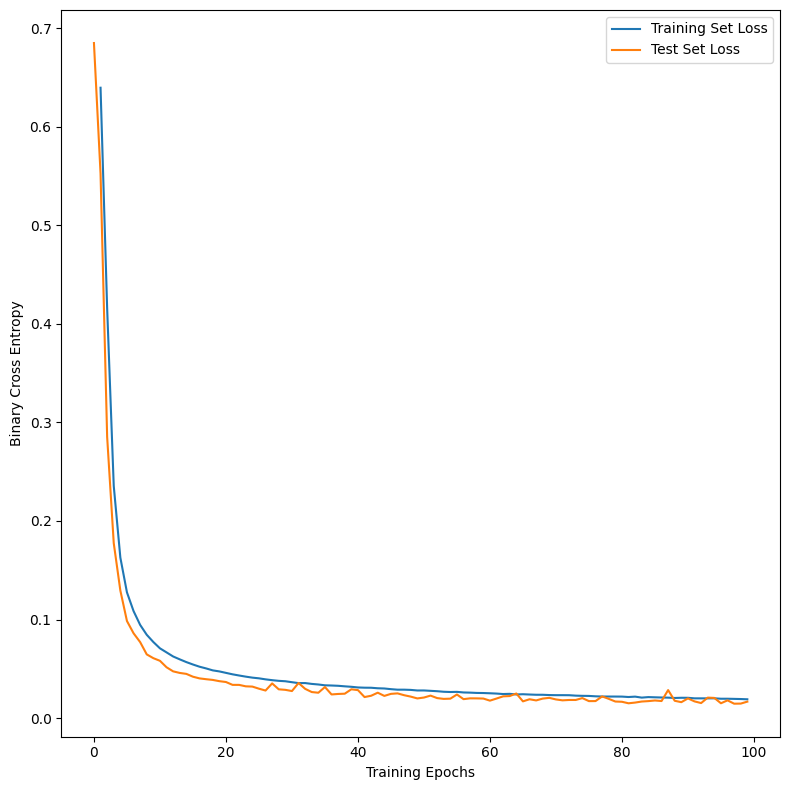

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.plot(
    range(1,EPOCHS), train_losses[1:], label='Training Set Loss'
)
ax.plot(
    range(EPOCHS), test_losses, label='Test Set Loss'
)
# for a in ax:
ax.legend()
ax.set_xlabel('Training Epochs')
ax.set_ylabel('Binary Cross Entropy')

plt.tight_layout()
plt.show()

In [105]:
import pandas as pd


pd.DataFrame((train_losses[-1], test_losses[-1]), columns=["BCE Loss of Final Model"], index=["Train Set", "Test Set"])

,BCE Loss of Final Model
Train Set,0.019069
Test Set,0.016689


#### Qualitative Example

In [106]:
# test run with 1 batch
for i, data in enumerate(stack_train_dl):
  gt, received, has_switched = data
  # print(gt.shape)
  sout = sender(gt) > 0.5
  rout = receiver(sout, received)
  break

has_switched ground truth: True
Model Prediction: has_switched = True


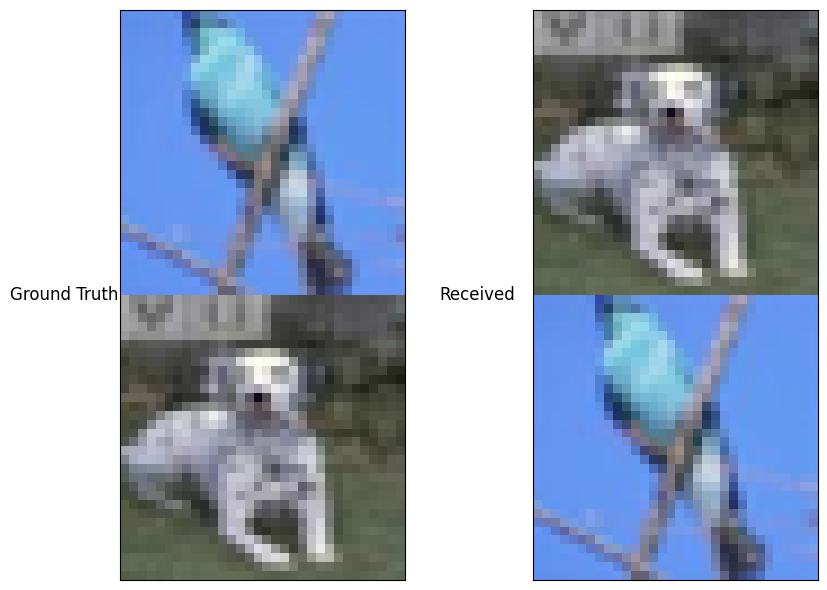

In [107]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

show_labeled([gt[0, ...]], "Ground Truth", ax1)
show_labeled([received[0, ...]], "Received", ax2)

print("has_switched ground truth:", has_switched[0, ...].item())
print("Model Prediction: has_switched =", "True" if rout[0, ...] > 0 else "False")
plt.tight_layout()
plt.show()

# Accuracy Metric
Our receiver outputs a logit. We can convert its prediction into binary prediction by thresholding:
* If the receiver prediction is greater than the threshold, let it predict `1` i.e. "The pictures have been switched"
* If the receiver prediction is lower (or equal) than the threshold, let it predict `0` i.e. "The pictures have NOT been switched"

For simplicity, we use `threshold = 0`. However, this threshold could be finetured on the training set.

In [108]:
correct = 0
total = 0

THRESHOLD = 0
with torch.no_grad():
  for i, data in enumerate(stack_train_dl): # on the training dataset
    gt, received, has_switched = data
    sout = sender(gt) > 0.5
    rout = receiver(sout, received)
    rout_thresh = rout > THRESHOLD

    correct += (rout_thresh.squeeze(-1) == has_switched).sum().item()
    total += has_switched.numel()


train_accuracy = correct / total

In [109]:
correct = 0
total = 0

with torch.no_grad():

  for i, data in enumerate(stack_train_dl): # on the test dataset
    gt, received, has_switched = data
    sout = sender(gt) > 0.5
    rout = receiver(sout, received)
    rout_thresh = rout > 0
    correct += (rout_thresh.squeeze(-1) == has_switched).sum().item()
    total += has_switched.numel()


test_accuracy = correct / total

In [110]:
import pandas as pd


pd.DataFrame((train_accuracy*100, test_accuracy*100), columns=["Accuracy of the Final Model"], index=["Train Set", "Test Set"])

,Accuracy of the Final Model
Train Set,99.593838
Test Set,99.635854


### Discussion of Results

The model's training is mostly stable and converges, although sometimes performance on the test set drops significantly, but recovers instantly. The instability on the test set is likely due to the small amount of images used (only 10).

The model does not overfit since the accuracy on the train set is mostly equal to the one on the train set.

The model's easily achieve `>99%` accuracy even by using 2 pixels per image. By inspecting the wrong prediction, one sees that the images are equal in the pixels the model uses, and thus

### Manual inspection of wrong predictions

In [111]:
# find all examples where the model's prediction is wrong
wrong_examples = []

for i, data in enumerate(stack_train_dl):
    gt, received, has_switched = data
    sout = sender(gt) > 0.5
    rout = receiver(sout, received) > 0

    for idx in range(BATCH_SIZE):

      if has_switched[idx, ...] != rout[idx, ...]:
        wrong_examples.append({
            'gt': gt[idx],
            'received': received[idx],
            'has_switched': has_switched[idx].item(),
            'predicted': rout[idx].item(),
        })

print(f"Total wrong examples: {len(wrong_examples)}")

Total wrong examples: 23


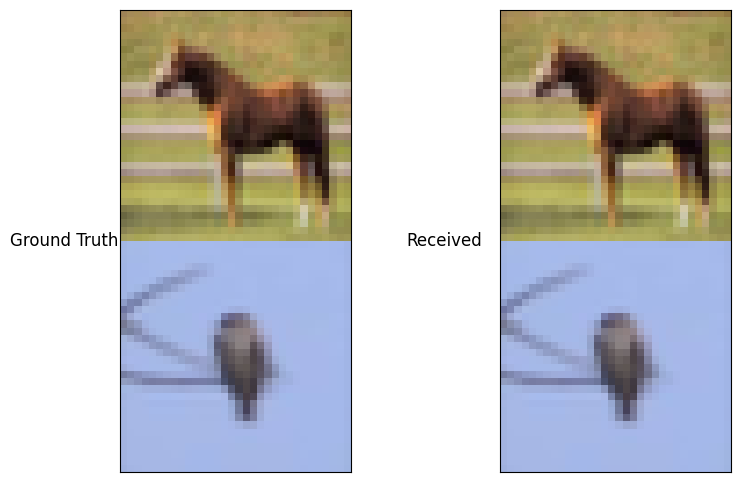

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

show_labeled([wrong_examples[3]['gt']], "Ground Truth", ax1)
show_labeled([wrong_examples[3]['gt']], "Received", ax2)
plt.show()